# Evaluating AI Coding Agents on Ontology Curation — Exploratory Analysis

*Standalone analysis notebook for the paper.* This is the working
document where we explore the evaluation results and develop the
findings. It is intentionally detailed and partly redundant with
`01_scores_overview` — read this one end-to-end.

## What we are measuring

We replay **real, merged pull requests** from four OBO ontologies
(Gene Ontology, Mondo, Uberon, Cell Ontology). For each curated
issue→PR case an agent is given the *issue* and the repository at the
PR's base commit, and must produce a PR. We then have **two independent
reviewing agents** (`claude` = Claude Opus 4.7, and `codex`) read the
issue, the human "gold" PR, and the agent's PR and assign an outcome.

**Why reviewer scores, not metadiff F1.** Metadiff F1 (token overlap of
the agent diff vs the single gold PR) is *too noisy* to anchor on:
roughly half the mined cases have a flawed gold (the issue is resolved
across several companion PRs, the gold leaked into the eval base, or the
linked PR does not actually resolve the issue), and even on clean cases
serialization artefacts swing F1. We therefore use the **reviewer
outcome verdict** as the primary measure, mapped to a score:

> `success` → 1.0  `partial_success` → 0.5  `failure`/`no_output` → 0.0

and (where both reviewers saw a PR) the **consensus** = mean of the two.
F1 is retained only as a secondary, noisy signal. §3 quantifies the F1
noise; §4 validates that the reviewer score is trustworthy before we
use it.


In [1]:
import os
while not os.path.exists('analysis/scores.tsv'):
    os.chdir('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, re, yaml
from pathlib import Path
from ai4c_scribe.analysis import (
    load_scores, load_reviews, attach_case_quality, pair_reviewers,
    cohen_kappa, reviewer_case_scores, paired_test, significance_summary,
    summary_by_model, pivot_scores, failure_mode_counts,
)
sns.set_theme(style='whitegrid', font_scale=1.05); pd.set_option('display.precision',3)

scores = attach_case_quality(load_scores('analysis/scores.tsv'))
scores['agent'] = pd.read_csv('analysis/scores.tsv', sep='\t')['agent'].values  # canonical
reviews = load_reviews()

rcs = reviewer_case_scores(reviews, scores)          # one rscore per (agent, case)
clear = rcs[rcs.case_quality != 'poor'].copy()       # the analysis universe
std = clear[clear.agent.str.startswith('std_')].copy()
STD = ['std_claude_op47','std_claude_son45','std_claude_hai45',
       'std_codex_g55','std_codex_g54','std_opencode_g55','std_opencode_g54',
       'std_copilot_son45','std_opencode_kimi','std_opencode_gem4']
print(f'{scores.case.nunique()} cases | {len(scores)} scored runs | '
      f'{len(reviews)} review files')
print(f'reviewer_case_scores: {len(rcs)} (agent,case) rows; '
      f'{len(clear)} on clear (non-poor) cases')


149 cases | 1662 scored runs | 3357 review files
reviewer_case_scores: 1186 (agent,case) rows; 621 on clear (non-poor) cases


## 1. The benchmark: cases

Cases are mined issue→PR pairs. Each is curated with a task type,
difficulty, scope, and — crucially — a **quality flag**. Curation
revealed that a large fraction of *real* merged PRs are unsuitable as a
single-gold target (the central methodological finding of the paper):


Cases per ontology:
ontology
cell-ontology    37
go-ontology      36
mondo            37
uberon           39

Case quality (the suitability finding):
case_quality
poor    73
ok      41
good    35

-> 49% of curated cases are NOT usable for automatic scoring and are excluded from all comparisons.


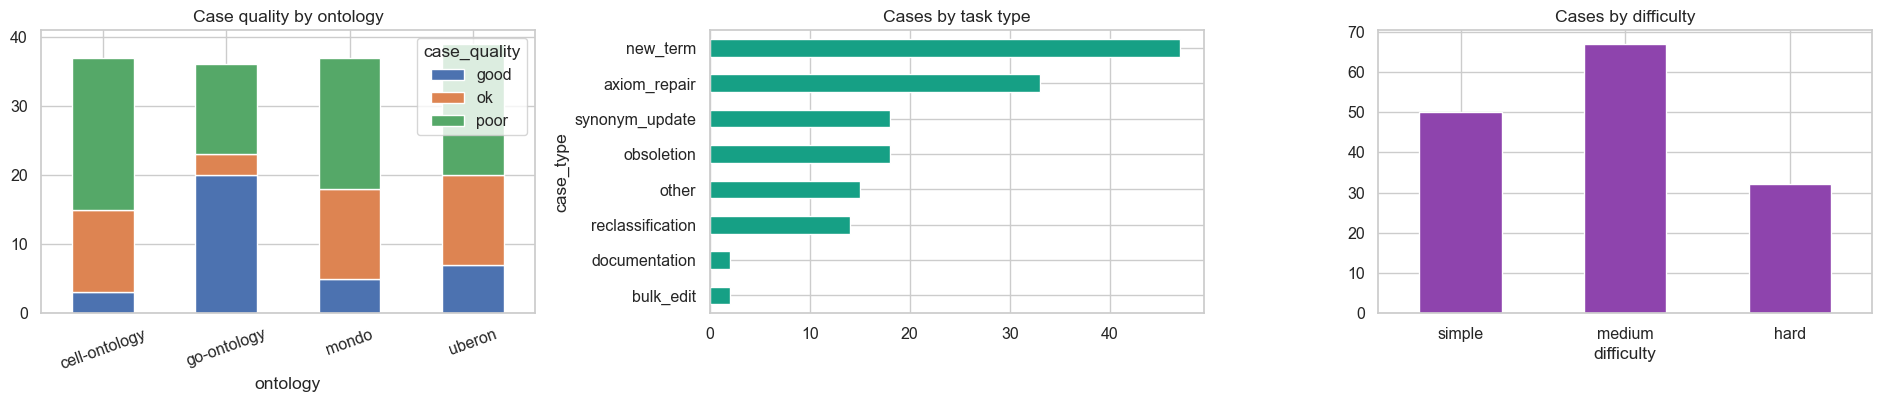

In [2]:
cases = scores.drop_duplicates('case')
print('Cases per ontology:'); print(cases.groupby('ontology').size().to_string())
print('\nCase quality (the suitability finding):')
print(cases['case_quality'].value_counts().to_string())
print(f"\n-> {(cases.case_quality=='poor').mean():.0%} of curated cases are NOT "
      "usable for automatic scoring and are excluded from all comparisons.")

fig, ax = plt.subplots(1, 3, figsize=(19,4.2))
cases.groupby(['ontology','case_quality']).size().unstack(fill_value=0).plot.bar(
    stacked=True, ax=ax[0]); ax[0].set_title('Case quality by ontology'); ax[0].tick_params(axis='x',rotation=20)
cases.groupby('case_type').size().sort_values().plot.barh(ax=ax[1], color='#16a085')
ax[1].set_title('Cases by task type')
cases.groupby('difficulty').size().reindex(['simple','medium','hard']).plot.bar(
    ax=ax[2], color='#8e44ad'); ax[2].set_title('Cases by difficulty'); ax[2].tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_cases.png',dpi=150); plt.show()


### 1a. What a case looks like (concrete examples)

To make the task concrete, here are real curated cases — the issue, the
human gold change, and the curator's quality assessment. (The agent only
sees the issue and the base repository.)


In [3]:
def show_case(issue):
    for f in Path('analysis').glob(f'*/cases/*/METADATA.md'):
        t = f.read_text()
        if re.search(rf'^issue_number:\s*{issue}\b', t, re.M):
            fm = yaml.safe_load(t[3:t.index('---',3)])
            print(f"--- {f.parts[1]}  issue #{fm.get('issue_number')}  (gold PR #{fm.get('pr_number')}) ---")
            print(f"  title      : {fm.get('issue_title')}")
            print(f"  task_type  : {fm.get('task_type')}  | difficulty: {fm.get('difficulty')}"
                  f"  | scope: {fm.get('scope')}")
            fc = fm.get('files_changed') or []
            print(f"  gold edits : " + ", ".join(f"{c.get('path','?')} (+{c.get('additions',0)}/-{c.get('deletions',0)})" for c in fc[:3]))
            print(f"  case_quality: {fm.get('case_quality','unflagged')}"
                  + (f" — {fm.get('case_quality_reason')}" if fm.get('case_quality_reason') else ""))
            cb = f.parent/'CASE_BRIEF.md'
            if cb.exists():
                body = cb.read_text()
                snippet = body.split('\n\n',2)
                print("  brief      : " + (snippet[1][:280].replace('\n',' ') if len(snippet)>1 else body[:280].replace('\n',' ')))
            return
# a clean simple case, a hard one, and a 'poor' one to illustrate the curation
for iss in ['3559','31670','5726']:
    show_case(iss); print()


--- cell-ontology  issue #3559  (gold PR #3564) ---
  title      : [Synonym] abbreviations like PBMC
  task_type  : synonym_update  | difficulty: simple  | scope: multi_term
  gold edits : src/ontology/cl-edit.owl (+3/-0)
  case_quality: ok — metadiff_underrepresents_substance
  brief      : # PR #3564 — [Synonym] abbreviations like PBMC

--- go-ontology  issue #31670  (gold PR #31676) ---
  title      : Taxon constraint: please add for GO:0070478 and similar terms
  task_type  : new_term  | difficulty: hard  | scope: multi_term
  gold edits : src/taxon_constraints/only_in_taxon.tsv (+4/-1)
  case_quality: poor — gold_pr_is_partial
  brief      : # PR #31676 — Taxon constraint: please add for GO:0070478 and similar terms

--- mondo  issue #5726  (gold PR #10155) ---
  title      : Add non-human animal diseases from VeNom
  task_type  : new_term  | difficulty: hard  | scope: structural_refactor
  gold edits : src/ontology/mondo-edit.obo (+9006/-0)
  case_quality: poor — gold_leakage_bas

## 2. The agents

An **agent** = (harness/runtime) × (model) × (config). The harness is
the coding CLI driving the model (Claude Code, Codex, OpenCode, Copilot
CLI, Gemini CLI); the model is the underlying LLM. This factorisation
lets us ask the two questions the paper cares about: *does the model
matter?* and *does the harness matter?*


In [4]:
tbl = (std.groupby('agent')
       .agg(n_cases=('case','nunique'), model=('model','first'),
            runtime=('runtime','first'), mean_rscore=('rscore','mean'))
       .round(3).reindex(STD).dropna(how='all').sort_values('mean_rscore',ascending=False))
print('Standard agents (clear cases):'); print(tbl.to_string())


Standard agents (clear cases):
                   n_cases              model   runtime  mean_rscore
agent                                                               
std_claude_op47         75    claude-opus-4.7    claude        0.820
std_codex_g55           56            gpt-5.5     codex        0.750
std_opencode_g55        72            gpt-5.5  opencode        0.742
std_claude_son45        76  claude-sonnet-4.5    claude        0.738
std_copilot_son45       39  claude-sonnet-4.5   copilot        0.731
std_opencode_gem4       32        gemma-4-31b  opencode        0.703
std_codex_g54           73            gpt-5.4     codex        0.702
std_opencode_g54        71            gpt-5.4  opencode        0.697
std_opencode_kimi       49          kimi-k2.6  opencode        0.696
std_claude_hai45        76   claude-haiku-4.5    claude        0.605


## 3. Why not F1 — quantifying the noise

If F1 tracked quality we would not need reviewers. It does not: within a
*single* reviewer verdict, F1 is spread all over the range. Reviewer
score and F1 correlate only weakly.


Clear-case PRs with both signals: n=835
Pearson r (reviewer vs F1) = 0.628; Spearman = 0.665

F1 distribution WITHIN each reviewer consensus level:
                 count   mean    std  median
consensus_score                             
0.00                28  0.211  0.220   0.125
0.25                17  0.212  0.222   0.167
0.50               373  0.500  0.291   0.500
0.75                59  0.709  0.160   0.706
1.00               358  0.855  0.196   0.922


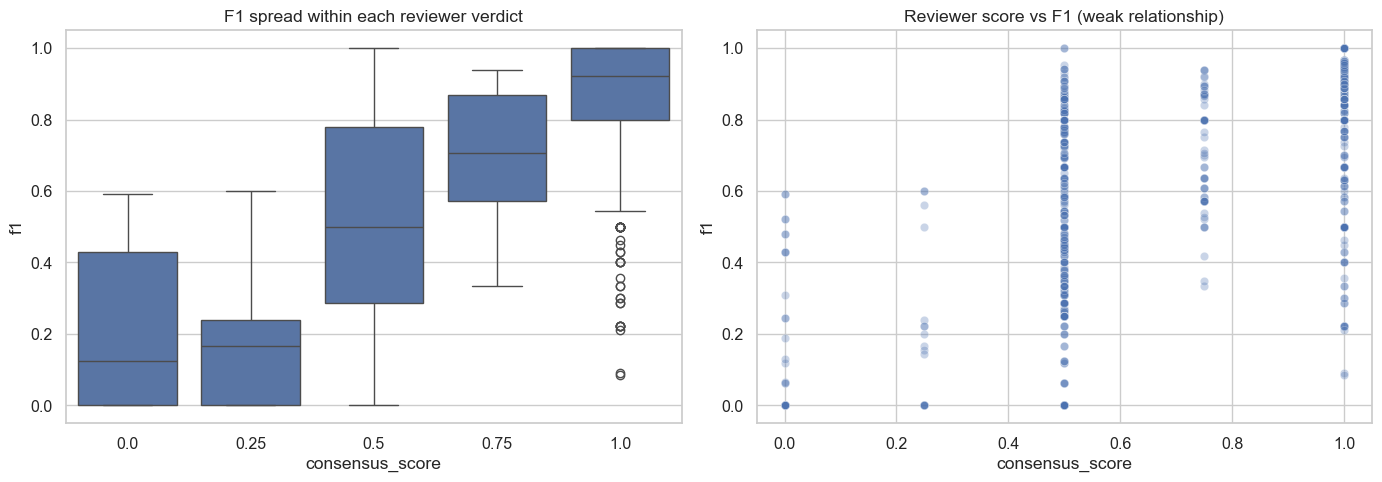

In [5]:
m = pair_reviewers(reviews).copy()
m['eval_repo_pr']=pd.to_numeric(m.eval_repo_pr,errors='coerce')
sj=scores.copy(); sj['eval_repo_pr']=pd.to_numeric(sj.eval_repo_pr,errors='coerce')
meta=sj.drop_duplicates(['ontology','eval_repo_pr']).set_index(['ontology','eval_repo_pr'])[['f1','case_quality']]
ix=m.set_index(['ontology','eval_repo_pr']).index
m['f1']=pd.to_numeric(ix.map(meta['f1']),errors='coerce'); m['cq']=ix.map(meta['case_quality'])
mc=m[(m.cq!='poor')].dropna(subset=['f1','consensus_score'])
print(f'Clear-case PRs with both signals: n={len(mc)}')
print(f"Pearson r (reviewer vs F1) = {mc.consensus_score.corr(mc.f1):.3f}; "
      f"Spearman = {mc.consensus_score.corr(mc.f1, method='spearman'):.3f}")
print('\nF1 distribution WITHIN each reviewer consensus level:')
print(mc.groupby('consensus_score')['f1'].agg(['count','mean','std','median']).round(3).to_string())
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.boxplot(data=mc, x='consensus_score', y='f1', ax=ax[0]); ax[0].set_title('F1 spread within each reviewer verdict')
sns.scatterplot(data=mc.sample(min(len(mc),1200),random_state=1), x='consensus_score', y='f1', alpha=.3, ax=ax[1])
ax[1].set_title('Reviewer score vs F1 (weak relationship)')
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_f1noise.png',dpi=150); plt.show()


## 4. Is the reviewer score trustworthy? (inter-annotator agreement)

Before using reviewer scores to rank agents we check the two reviewing
agents agree. *Paired* = the same eval PR independently reviewed by both
`claude` and `codex`.


Paired reviews: 761
Exact outcome agreement : 0.717
3-point score agreement  : 0.723
Mean |Δ score|           : 0.147
Cohen's kappa (nominal)  : 0.518
Weighted kappa (linear)  : 0.559
Harshness: claude mean 0.682 vs codex 0.564


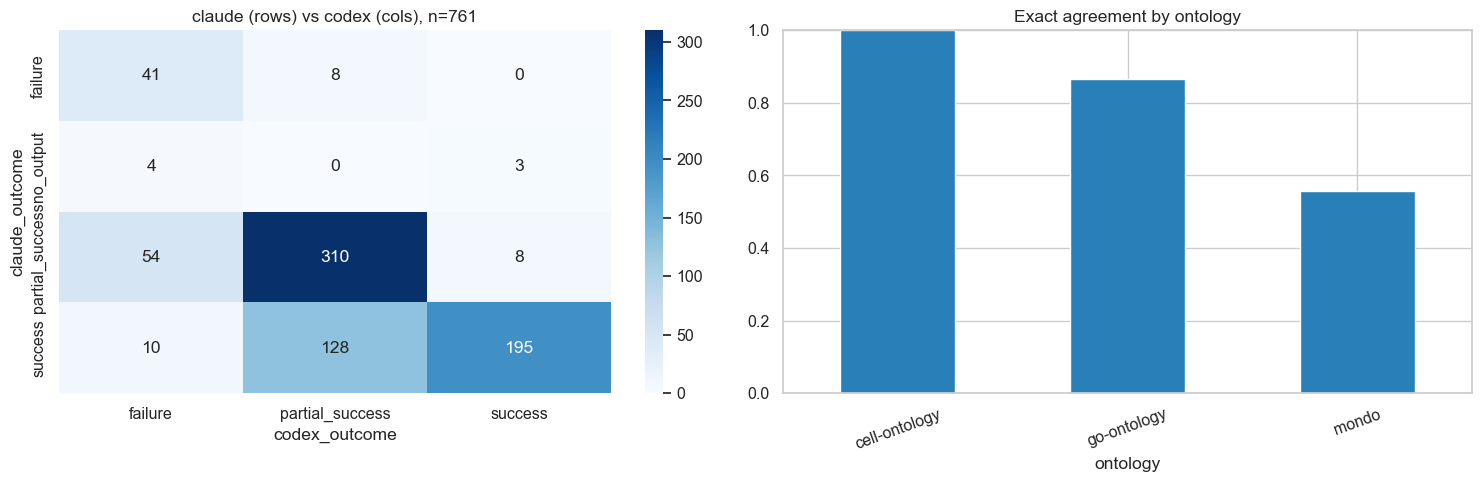


By ontology:
                   n  exact  kappa
ontology                          
cell-ontology   15.0  1.000  1.000
go-ontology    376.0  0.864  0.755
mondo          370.0  0.557  0.240


In [6]:
p = pair_reviewers(reviews)
both = p.dropna(subset=['claude_score','codex_score']).copy()
n=len(both)
print(f'Paired reviews: {n}')
print(f'Exact outcome agreement : {(both.claude_outcome==both.codex_outcome).mean():.3f}')
print(f'3-point score agreement  : {(both.claude_score==both.codex_score).mean():.3f}')
print(f'Mean |Δ score|           : {(both.claude_score-both.codex_score).abs().mean():.3f}')
print(f"Cohen's kappa (nominal)  : {cohen_kappa(both.claude_outcome,both.codex_outcome):.3f}")
print(f'Weighted kappa (linear)  : {cohen_kappa(both.claude_score,both.codex_score,weights="linear"):.3f}')
print(f'Harshness: claude mean {both.claude_score.mean():.3f} vs codex {both.codex_score.mean():.3f}')
fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.heatmap(pd.crosstab(both.claude_outcome,both.codex_outcome),annot=True,fmt='d',cmap='Blues',ax=ax[0])
ax[0].set_title(f'claude (rows) vs codex (cols), n={n}')
byo=both.groupby('ontology').apply(lambda g: pd.Series({'n':len(g),
     'exact':(g.claude_outcome==g.codex_outcome).mean(),
     'kappa':cohen_kappa(g.claude_outcome,g.codex_outcome) if len(g)>3 else np.nan}))
byo['exact'].plot.bar(ax=ax[1],color='#2980b9'); ax[1].set_ylim(0,1)
ax[1].set_title('Exact agreement by ontology'); ax[1].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_iaa.png',dpi=150); plt.show()
print('\nBy ontology:'); print(byo.round(3).to_string())


**Interpretation.** Agreement is in the *moderate–substantial* range
(κ≈0.5 nominal, higher weighted); the dominant disagreement is the soft
`partial`↔`success` boundary, not hard `success`↔`failure` flips, and
`codex` is consistently the harsher reviewer. Agreement is strong on GO,
weak on Mondo — Mondo reviewer scores carry more uncertainty and we flag
that wherever Mondo-specific conclusions are drawn. Using the
**consensus** (mean of both reviewers) cancels per-reviewer harshness.


## 5. Worked examples — what the reviewers actually saw

Numbers are only meaningful if grounded in cases. Below, for a few
clear cases, we show the reviewers' own written assessment of specific
agent attempts (success, partial, failure), so the score scale is
legible.


In [7]:
def review_excerpt(ontology, eval_pr, reviewer='claude', n=600):
    d=Path(f'analysis/{ontology}/results/reviews')
    for f in sorted(d.glob(f'pr{eval_pr}-*{reviewer}*-complete.md')):
        t=f.read_text(); body=t[t.index('---',3)+3:].strip()
        return f.name, body[:n]
    return None, None

ex = std.dropna(subset=['rscore']).copy()
shown=set()
for tgt,label in [(1.0,'SUCCESS'),(0.5,'PARTIAL'),(0.0,'FAILURE')]:
    row = ex[(ex.rscore==tgt) & (~ex.case.isin(shown))].sort_values('agent').head(1)
    if row.empty: continue
    r=row.iloc[0]; shown.add(r['case'])
    # find an eval PR for this (agent, case)
    pp=pair_reviewers(reviews)
    pp['eval_repo_pr']=pd.to_numeric(pp.eval_repo_pr,errors='coerce')
    sj2=scores.copy(); sj2['eval_repo_pr']=pd.to_numeric(sj2.eval_repo_pr,errors='coerce')
    cand=sj2[(sj2.agent==r['agent'])&(sj2.case==r['case'])].dropna(subset=['eval_repo_pr'])
    if cand.empty: continue
    epr=int(cand.iloc[0]['eval_repo_pr']); ont=cand.iloc[0]['ontology']
    print(f"===== {label}: {r['agent']} on {r['case']} ({r['case_type']}, {r['difficulty']}) — reviewer score {tgt} =====")
    fn,exc=review_excerpt(ont,epr,'claude')
    if exc: print(f"[claude review {fn}]\n{exc}\n")
    fn,exc=review_excerpt(ont,epr,'codex')
    if exc: print(f"[codex review {fn}]\n{exc}\n")


===== SUCCESS: std_claude_hai45 on cel#3382 (axiom_repair, simple) — reviewer score 1.0 =====
[claude review pr96-claude-complete.md]
## Summary

claude-haiku-4.5 (claude) produced the exactly correct fix for issue #3382:
replacing `BFO_0000051` (has_part) with `RO_0002104` (has_plasma_membrane_part)
for `PR_000001207` (CXCR3) in the `EquivalentClasses` axiom of CL:0001041
(CD8-positive, CXCR3-positive, alpha-beta regulatory T cell). The agent's diff
is byte-identical to the merged gold human PR #3440 (blob `515bbaa`). The
F1=1.0 is genuine and accurately represents quality — this is the literal
minimal one-line substitution the issue requested, independently reproduced
(not a leaked/contaminated artifact; the gold is a sing

[codex review pr96-codex-complete.md]
## Summary

The attempt is exactly correct. It replaces `BFO_0000051` with `RO_0002104` for
the CXCR3 plasma-membrane marker restriction in `CL_0001041`.

This matches the gold PR line-for-line.

## Strengths

The edit is mini

===== PARTIAL: std_claude_hai45 on cel#3243 (axiom_repair, medium) — reviewer score 0.5 =====
[claude review pr89-claude-complete.md]
## Summary

The agent did the surface portion of issue #3243 well — renamed CL_0000135 to "circulating fibrocyte", installed the issue's literature definition with the right PMID set, and added the "monocyte-derived fibrocyte" narrow synonym — but it **did not update the logical definition at all**, leaving the obsolete `EquivalentClasses(... GO_0002495 ... GO_0045766)` and the now-incorrect `develops_from some CL_0000057` (fibroblast) axioms in place. Because the issue's central ask was a *logical* def revision (the title is "[Text and logical def] fibrocyte"), this is a partial success. F1 o

[codex review pr89-codex-complete.md]
## Summary

The attempt performs the surface text changes but misses the central logical
definition repair. It renames fibrocyte to circulating fibrocyte, replaces the
definition, and adds the monocyte-derived fibrocyte synony

===== FAILURE: std_claude_hai45 on cel#3333 (axiom_repair, simple) — reviewer score 0.0 =====
[claude review pr145-claude-complete.md]
## Summary

Identical outcome to attempt #202 (same `17912f0` blob): the agent removed the
six genuinely redundant `oboInOwl:*` synonym/xref labels (correct) but also
deleted the `rdfs:label` axioms for `obo:IAO_0000028` ("symbol"),
`oboInOwl:SubsetProperty`, `oboInOwl:consider`, `oboInOwl:inSubset`, and
`rdfs:seeAlso`, none of which is labeled in `merged_import.owl`. That is
information loss, not redundant cleanup. F1=0.522 accurately represents
genuinely worse work; this is a correctness error, not a metadiff artifact.

## Strengths

- Correctly removed the six properties whose labels are re

[codex review pr145-codex-complete.md]
## Summary

This attempt removes the six redundant `oboInOwl:*` synonym/xref labels that the
human PR removed, but it also deletes five labels that should have stayed:
`obo:IAO_0000028`, `oboInOwl:SubsetProperty`, `oboInOwl:

## 6. Exploratory questions

All tests below are **paired** on the cases two agents *share* (each
case contributes one mean reviewer score per agent), restricted to
clear cases. We report mean difference, paired-t and Wilcoxon p-values,
Cohen's d, and n shared. "Significant" = p<0.05 (exploratory; not
multiplicity-corrected — this is the exploration stage).


### Q1. Does the model matter? (same harness, Claude Code: Opus vs Sonnet vs Haiku)

std_claude_son45  vs  std_claude_op47:  n= 75  mean 0.741 vs 0.820  Δ=-0.079  t-p=0.02438  wilcoxon-p=0.03491  d=-0.27  SIG
std_claude_hai45  vs  std_claude_son45:  n= 76  mean 0.605 vs 0.738  Δ=-0.133  t-p=1.849e-05  wilcoxon-p=6.403e-05  d=-0.52  SIG


std_claude_hai45  vs  std_claude_op47:  n= 75  mean 0.607 vs 0.820  Δ=-0.213  t-p=4.856e-08  wilcoxon-p=1.551e-06  d=-0.70  SIG


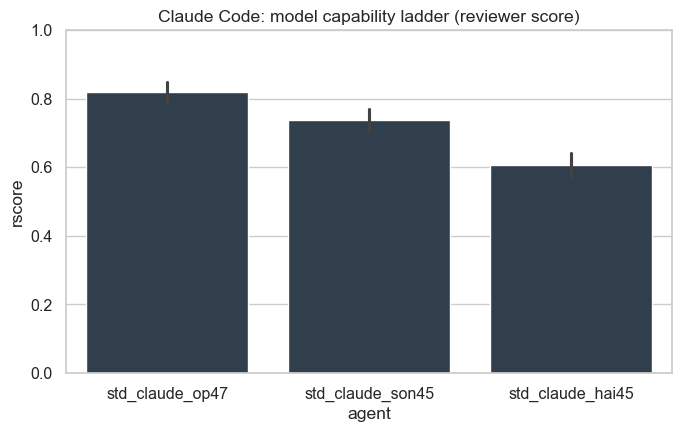

In [8]:
def head2head(a,b,df=std):
    r=paired_test(df,a,b,score_col='rscore')
    if not r: print(f'{a} vs {b}: insufficient shared cases'); return
    print(f"{b}  vs  {a}:  n={r['n_shared']:3}  "
          f"mean {r['mean_b']:.3f} vs {r['mean_a']:.3f}  Δ={r['mean_b']-r['mean_a']:+.3f}  "
          f"t-p={r['p_value_ttest']:.4g}  wilcoxon-p={r['p_value_wilcoxon']:.4g}  "
          f"d={r['cohens_d']:+.2f}  {'SIG' if r['significant'] else 'ns'}")
for a,b in [('std_claude_op47','std_claude_son45'),
            ('std_claude_son45','std_claude_hai45'),
            ('std_claude_op47','std_claude_hai45')]:
    head2head(a,b)
sub=std[std.agent.isin(['std_claude_op47','std_claude_son45','std_claude_hai45'])]
fig,ax=plt.subplots(figsize=(7,4.5))
order=['std_claude_op47','std_claude_son45','std_claude_hai45']
sns.barplot(data=sub,x='agent',y='rscore',order=order,errorbar='se',ax=ax,color='#2c3e50')
ax.set_title('Claude Code: model capability ladder (reviewer score)'); ax.set_ylim(0,1)
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_q1.png',dpi=150); plt.show()


**Read:** a clear capability ladder within a fixed harness —
Opus > Sonnet > Haiku on reviewer-judged quality. The Opus–Haiku gap is
large and highly significant; Opus–Sonnet is smaller. This is the
single biggest effect in the study: *model choice dominates*.


### Q2. GPT-5.5 vs GPT-5.4 (same harness)

In [9]:
for a,b in [('std_codex_g54','std_codex_g55'),('std_opencode_g54','std_opencode_g55')]:
    head2head(a,b)


std_codex_g55  vs  std_codex_g54:  n= 56  mean 0.750 vs 0.728  Δ=+0.022  t-p=0.48  wilcoxon-p=0.481  d=+0.10  ns


std_opencode_g55  vs  std_opencode_g54:  n= 71  mean 0.743 vs 0.697  Δ=+0.046  t-p=0.1142  wilcoxon-p=0.07807  d=+0.19  ns


*Read:* whether the newer GPT revision helps, holding the harness fixed (codex; opencode).

### Q3. Does the harness matter? (same model, different CLI)

In [10]:
print('Same model gpt-5.5, harness codex vs opencode:')
head2head('std_codex_g55','std_opencode_g55')
print('\nSame model gpt-5.4, harness codex vs opencode:')
head2head('std_codex_g54','std_opencode_g54')
print('\nSame model claude-sonnet-4.5, harness Claude Code vs Copilot CLI:')
head2head('std_claude_son45','std_copilot_son45')


Same model gpt-5.5, harness codex vs opencode:
std_opencode_g55  vs  std_codex_g55:  n= 55  mean 0.772 vs 0.755  Δ=+0.017  t-p=0.54  wilcoxon-p=0.5207  d=+0.08  ns

Same model gpt-5.4, harness codex vs opencode:


std_opencode_g54  vs  std_codex_g54:  n= 71  mean 0.697 vs 0.704  Δ=-0.007  t-p=0.8227  wilcoxon-p=0.7259  d=-0.03  ns

Same model claude-sonnet-4.5, harness Claude Code vs Copilot CLI:


std_copilot_son45  vs  std_claude_son45:  n= 39  mean 0.731 vs 0.707  Δ=+0.024  t-p=0.5594  wilcoxon-p=0.6727  d=+0.09  ns


**Read:** the headline harness question. If these are *not*
significant while Q1 *is*, the story is "the model carries the result,
the harness is largely interchangeable at a given model tier" — a
robustness result worth stating plainly.


### Q4. Open-weight vs proprietary, and the full pairwise matrix

In [11]:
print('Open-weight (via OpenCode) vs proprietary on shared clear cases:')
for a,b in [('std_opencode_g55','std_opencode_kimi'),
            ('std_opencode_g55','std_opencode_gem4'),
            ('std_claude_son45','std_opencode_kimi')]:
    head2head(a,b)
print('\nFull pairwise significance matrix (clear cases, reviewer score):')
ss=significance_summary(std, agents=[a for a in STD if a in std.agent.unique()], score_col='rscore')
cols=['agent_a','agent_b','n_shared','mean_a','mean_b','mean_diff','p_value_ttest','cohens_d','significant']
print(ss[cols].sort_values('p_value_ttest').round(4).to_string(index=False))


Open-weight (via OpenCode) vs proprietary on shared clear cases:
std_opencode_kimi  vs  std_opencode_g55:  n= 49  mean 0.696 vs 0.733  Δ=-0.037  t-p=0.3116  wilcoxon-p=0.303  d=-0.15  ns


std_opencode_gem4  vs  std_opencode_g55:  n= 31  mean 0.694 vs 0.823  Δ=-0.129  t-p=0.03082  wilcoxon-p=0.03442  d=-0.41  SIG


std_opencode_kimi  vs  std_claude_son45:  n= 49  mean 0.696 vs 0.706  Δ=-0.009  t-p=0.7901  wilcoxon-p=0.592  d=-0.04  ns

Full pairwise significance matrix (clear cases, reviewer score):


          agent_a           agent_b  n_shared  mean_a  mean_b  mean_diff  p_value_ttest  cohens_d  significant
  std_claude_op47  std_claude_hai45        75   0.820   0.607     -0.213      0.000e+00    -0.702         True
 std_claude_son45  std_claude_hai45        76   0.738   0.605     -0.133      0.000e+00    -0.525         True
 std_claude_hai45  std_opencode_g55        72   0.597   0.742      0.145      0.000e+00     0.527         True
 std_claude_hai45     std_codex_g54        73   0.589   0.702      0.113      3.000e-04     0.440         True
 std_claude_hai45     std_codex_g55        56   0.607   0.750      0.143      1.000e-03     0.463         True
 std_claude_hai45 std_opencode_kimi        49   0.582   0.696      0.115      1.200e-03     0.491         True
  std_claude_op47     std_codex_g54        72   0.812   0.705     -0.108      3.200e-03    -0.360         True
 std_claude_hai45 std_copilot_son45        39   0.596   0.731      0.135      3.300e-03     0.502         True
 

### Q5. Where do agents struggle? (slices by task type, difficulty, ontology)


Mean reviewer score by case_type x model tier (clear cases):
agent             std_claude_op47  std_claude_son45  std_claude_hai45  std_codex_g55  std_opencode_g55
case_type                                                                                             
axiom_repair                0.895             0.789             0.737          0.750             0.861
documentation               0.750             0.750             0.750          0.750             1.000
new_term                    0.847             0.819             0.514          0.614             0.637
obsoletion                  0.833             0.736             0.646          0.938             0.865
other                       0.562             0.594             0.438          0.600             0.562
reclassification            1.000             0.821             0.750          0.821             0.768
synonym_update              0.694             0.550             0.475          0.679             0.611

Mean revie

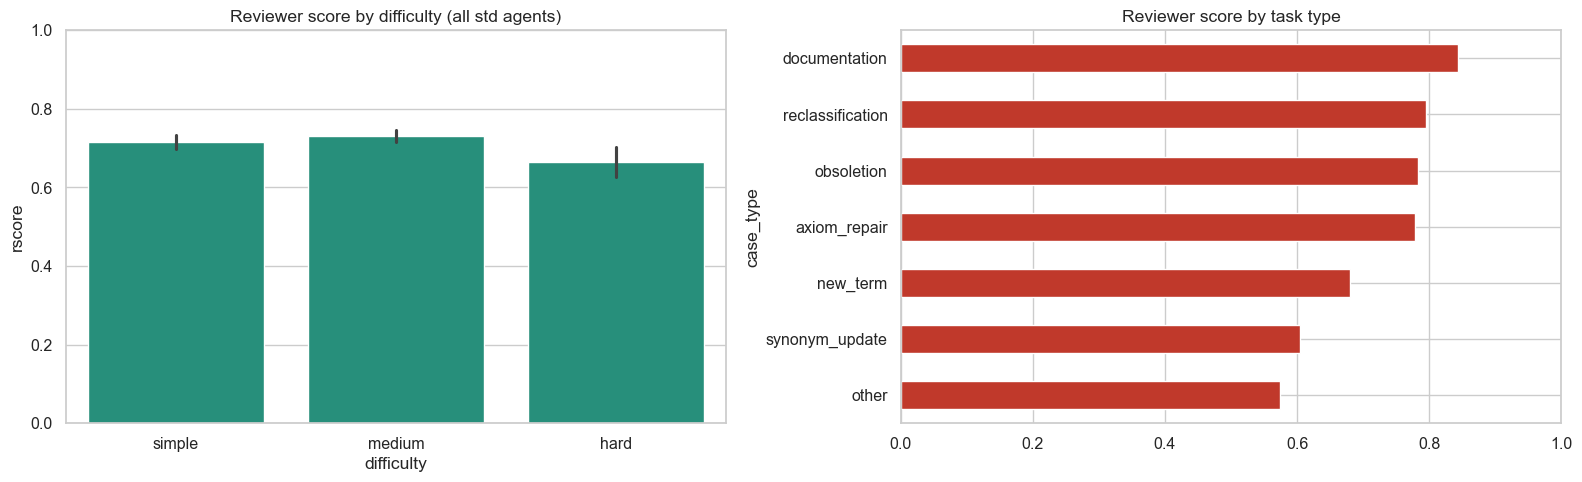

In [12]:
for by in ['case_type','difficulty','ontology']:
    print(f'\nMean reviewer score by {by} x model tier (clear cases):')
    piv=std.pivot_table(values='rscore', index=by,
        columns=std['agent'], aggfunc='mean')
    keep=[a for a in ['std_claude_op47','std_claude_son45','std_claude_hai45',
                      'std_codex_g55','std_opencode_g55'] if a in piv.columns]
    print(piv[keep].round(3).to_string())
fig,ax=plt.subplots(1,2,figsize=(16,5))
sns.barplot(data=std,x='difficulty',y='rscore',order=['simple','medium','hard'],
            errorbar='se',ax=ax[0],color='#16a085'); ax[0].set_ylim(0,1)
ax[0].set_title('Reviewer score by difficulty (all std agents)')
ct=std.groupby('case_type')['rscore'].mean().sort_values()
ct.plot.barh(ax=ax[1],color='#c0392b'); ax[1].set_xlim(0,1); ax[1].set_title('Reviewer score by task type')
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_pp_slices.png',dpi=150); plt.show()


### Q6. What do agents get wrong? (failure-mode taxonomy)

Failure modes across non-success reviews:
missed_requirement       1235
over_editing             1109
under_editing            1052
wrong_pattern             632
scope_creep               284
wrong_term                125
instruction_violation      76
syntax_error               75
no_changes                 16
missing_metadata           10
gold_orcid_source           7
placeholder_id              4


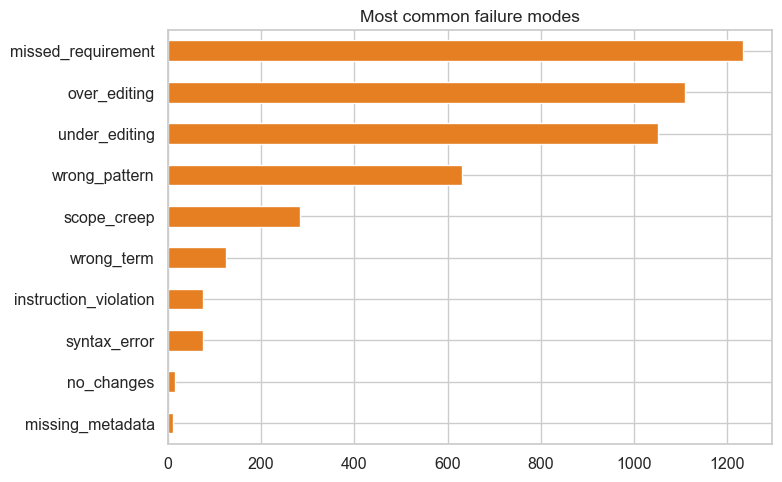

In [13]:
rv=reviews.copy()
rv['reviewer']=rv['_file'].map(lambda s: 'claude' if 'claude' in str(s) else ('codex' if 'codex' in str(s) else None))
fm=failure_mode_counts(rv[rv.outcome.isin(['failure','partial_success'])])
print('Failure modes across non-success reviews:'); print(fm.head(12).to_string() if fm is not None else 'n/a')
if fm is not None:
    fig,ax=plt.subplots(figsize=(8,5)); fm.head(10).plot.barh(ax=ax,color='#e67e22')
    ax.invert_yaxis(); ax.set_title('Most common failure modes'); plt.tight_layout()
    plt.savefig('analysis/notebooks/fig_pp_failuremodes.png',dpi=150); plt.show()


## 7. Discussion & limitations

**Findings (exploratory).**
- *Model dominates.* Within a fixed harness the model tier produces the
  largest, most robust effect (Q1: Opus > Sonnet > Haiku).
- *Harness is largely interchangeable* at a given model tier (Q3) — the
  same model under different CLIs is statistically indistinguishable on
  reviewer-judged quality where tested.
- *Difficulty and task type structure performance* (Q5): all agents
  degrade on hard / open-ended task types.
- The reviewer score is a **stable** measure (§4) and a *better* basis
  than F1 (§3, weak correlation, huge within-verdict F1 spread).

**Limitations.**
- The reviewers are themselves LLM agents; IAA (§4) bounds confidence.
  Mondo agreement is weak — treat Mondo-specific numbers cautiously.
- p-values here are exploratory and **not** multiplicity-corrected;
  confirmatory tests should pre-register the key contrasts (Q1, Q3).
- ~half of mined real PRs are unsuitable as single-gold targets
  (§1) — a result in itself, and the reason this notebook is
  reviewer-anchored.

### Coverage caveat — structural no-coverage cases

Over the fillable universe all six target agents are ~fully covered;
four (agent, case) slots are accepted as measured outcomes (the agent
deterministically produces no committed edit, or the eval-base step
fails for every agent): cell #3163 (all agents), cell #3559 / Opus,
go #19185, uberon #3591. These are excluded by the same logic as
`case_quality: poor`.
